# Summary Figure — Predicting Ocean pCO₂ from Satellite Data

This notebook generates a single **6-panel summary figure** that tells the full story of the project,
from geographic context through data exploration to ML results.

**Panels:**
- **(A)** Map of the 7 NOAA buoy sites
- **(B)** SST vs pCO₂ scatter — the core physical relationship
- **(C)** Data availability timeline by site
- **(D)** Model comparison (RMSE & R²)
- **(E)** Predicted vs Actual for the best model
- **(F)** Feature importance from Random Forest

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sns.set_theme(style="whitegrid", font_scale=1.0)
print("Ready.")

Ready.


In [175]:
PROJECT_ROOT = Path(r"C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\ML2026_Orrand")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PLOT_DIR = PROJECT_ROOT / "final project deliverables"

In [176]:
# ──────────────────────────────────────────────
# Load all data needed for the 6 panels
# ──────────────────────────────────────────────

# 1) ML-ready training data (for panels A, B, D, E, F)
df = pd.read_csv(PROCESSED_DIR / "training_data_700_ml_ready.csv")
df["date"] = pd.to_datetime(df["date"])

# 2) Continuous data periods (for panel C — data availability)
periods = pd.read_csv(PROCESSED_DIR / "buoy_continuous_data_periods.csv")
periods["segment_start"] = pd.to_datetime(periods["segment_start"])
periods["segment_end"]   = pd.to_datetime(periods["segment_end"])

# Quick reference: one lat/lon per site
site_coords = (
    df.groupby("location")[["latitude", "longitude"]]
    .median()
    .reset_index()
)

print(f"Training data: {len(df)} rows, {df['location'].nunique()} sites")
print(f"Data periods:  {len(periods)} continuous segments")
print()
print(site_coords.to_string(index=False))

Training data: 479 rows, 7 sites
Data periods:  35 continuous segments

           location  latitude  longitude
      First Landing    36.998    -76.088
 Grays Reef Georgia    31.399    -80.869
            LA Buoy    28.869    -90.480
            La Push    47.964   -124.958
      SE Bering Sea    56.865   -164.065
      South Pacific    -0.001   -154.919
Southern California    34.308   -120.814


In [177]:
# ──────────────────────────────────────────────
# Re-train models (quick — needed for panels D, E, F)
# ──────────────────────────────────────────────

FEATURE_COLS = [
    "latitude", "longitude", "sst_in_situ_mean",
    "sat_sst_mean", "sat_sst_std", "sat_sst_min", "sat_sst_max",
    "sat_sst_median", "sat_sst_closest",
    "sat_chla_mean", "sat_chla_std", "sat_chla_min", "sat_chla_max",
    "sat_chla_median", "sat_chla_closest", "chla_days_offset",
]
TARGET = "pco2_mean"

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=df["location"]
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_COLS, index=X_test.index)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        random_state=42, n_jobs=-1),
}

results = []
predictions = {}

for name, model in models.items():
    if "Linear" in name:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results.append({"Model": name, "RMSE": round(rmse, 1), "MAE": round(mae, 1), "R2": round(r2, 3)})
    predictions[name] = y_pred
    print(f"{name:25s}  RMSE={rmse:.1f}  MAE={mae:.1f}  R²={r2:.3f}")

results_df = pd.DataFrame(results)
best_name = results_df.loc[results_df["RMSE"].idxmin(), "Model"]
print(f"\nBest model: {best_name}")

Linear Regression          RMSE=83.3  MAE=55.6  R²=0.281
Random Forest              RMSE=71.8  MAE=43.6  R²=0.465

Best model: Random Forest


In [178]:
# ── Save ────────────────────────────────────────────────────
# Add more vertical space between title and panels
fig.suptitle('Predicting Ocean pCO$_2$ from Satellite Data — Project Summary', fontsize=16, fontweight='bold', y=0.99)  # Use mathtext for subscript 2
plt.subplots_adjust(top=0.75)  # Lower the top further for more space below the title
# Remove previous panel letters from axes (no overlay)
for ax in [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]:
    texts_to_remove = [t for t in ax.texts if not (t is ax.title or t is ax.xaxis.label or t is ax.yaxis.label)]
    for t in texts_to_remove:
        t.remove()
# Add boxed panel letters just above each subplot (top left, outside axes)
axes_list = [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']
for ax, label in zip(axes_list, panel_labels):
    bbox = ax.get_position()
    fig.text(bbox.x0, bbox.y1 + 0.01, label, ha='left', va='bottom', fontsize=12, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
# Ensure the output directory exists before saving the figure
PLOT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_DIR / "summary_figure_6panel.png", dpi=200, bbox_inches="tight", facecolor="white")
save_path = PLOT_DIR / "summary_figure_6panel.pdf"
fig.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → {save_path}")
# (Caption is now removed from the figure for a separate page)

C:\Users\Owner\AppData\Local\Temp\ipykernel_8656\676456577.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(PLOT_DIR / "summary_figure_6panel.png", dpi=200, bbox_inches="tight", facecolor="white")
C:\Users\Owner\AppData\Local\Temp\ipykernel_8656\676456577.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(PLOT_DIR / "summary_figure_6panel.png", dpi=200, bbox_inches="tight", facecolor="white")
C:\Users\Owner\AppData\Local\Temp\ipykernel_8656\676456577.py:21: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
C:\Users\Owner\AppData\Local\Temp\ipykernel_8656\676456577.py:21: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")


<Figure size 640x480 with 0 Axes>


Saved → C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\ML2026_Orrand\final project deliverables\summary_figure_6panel.pdf


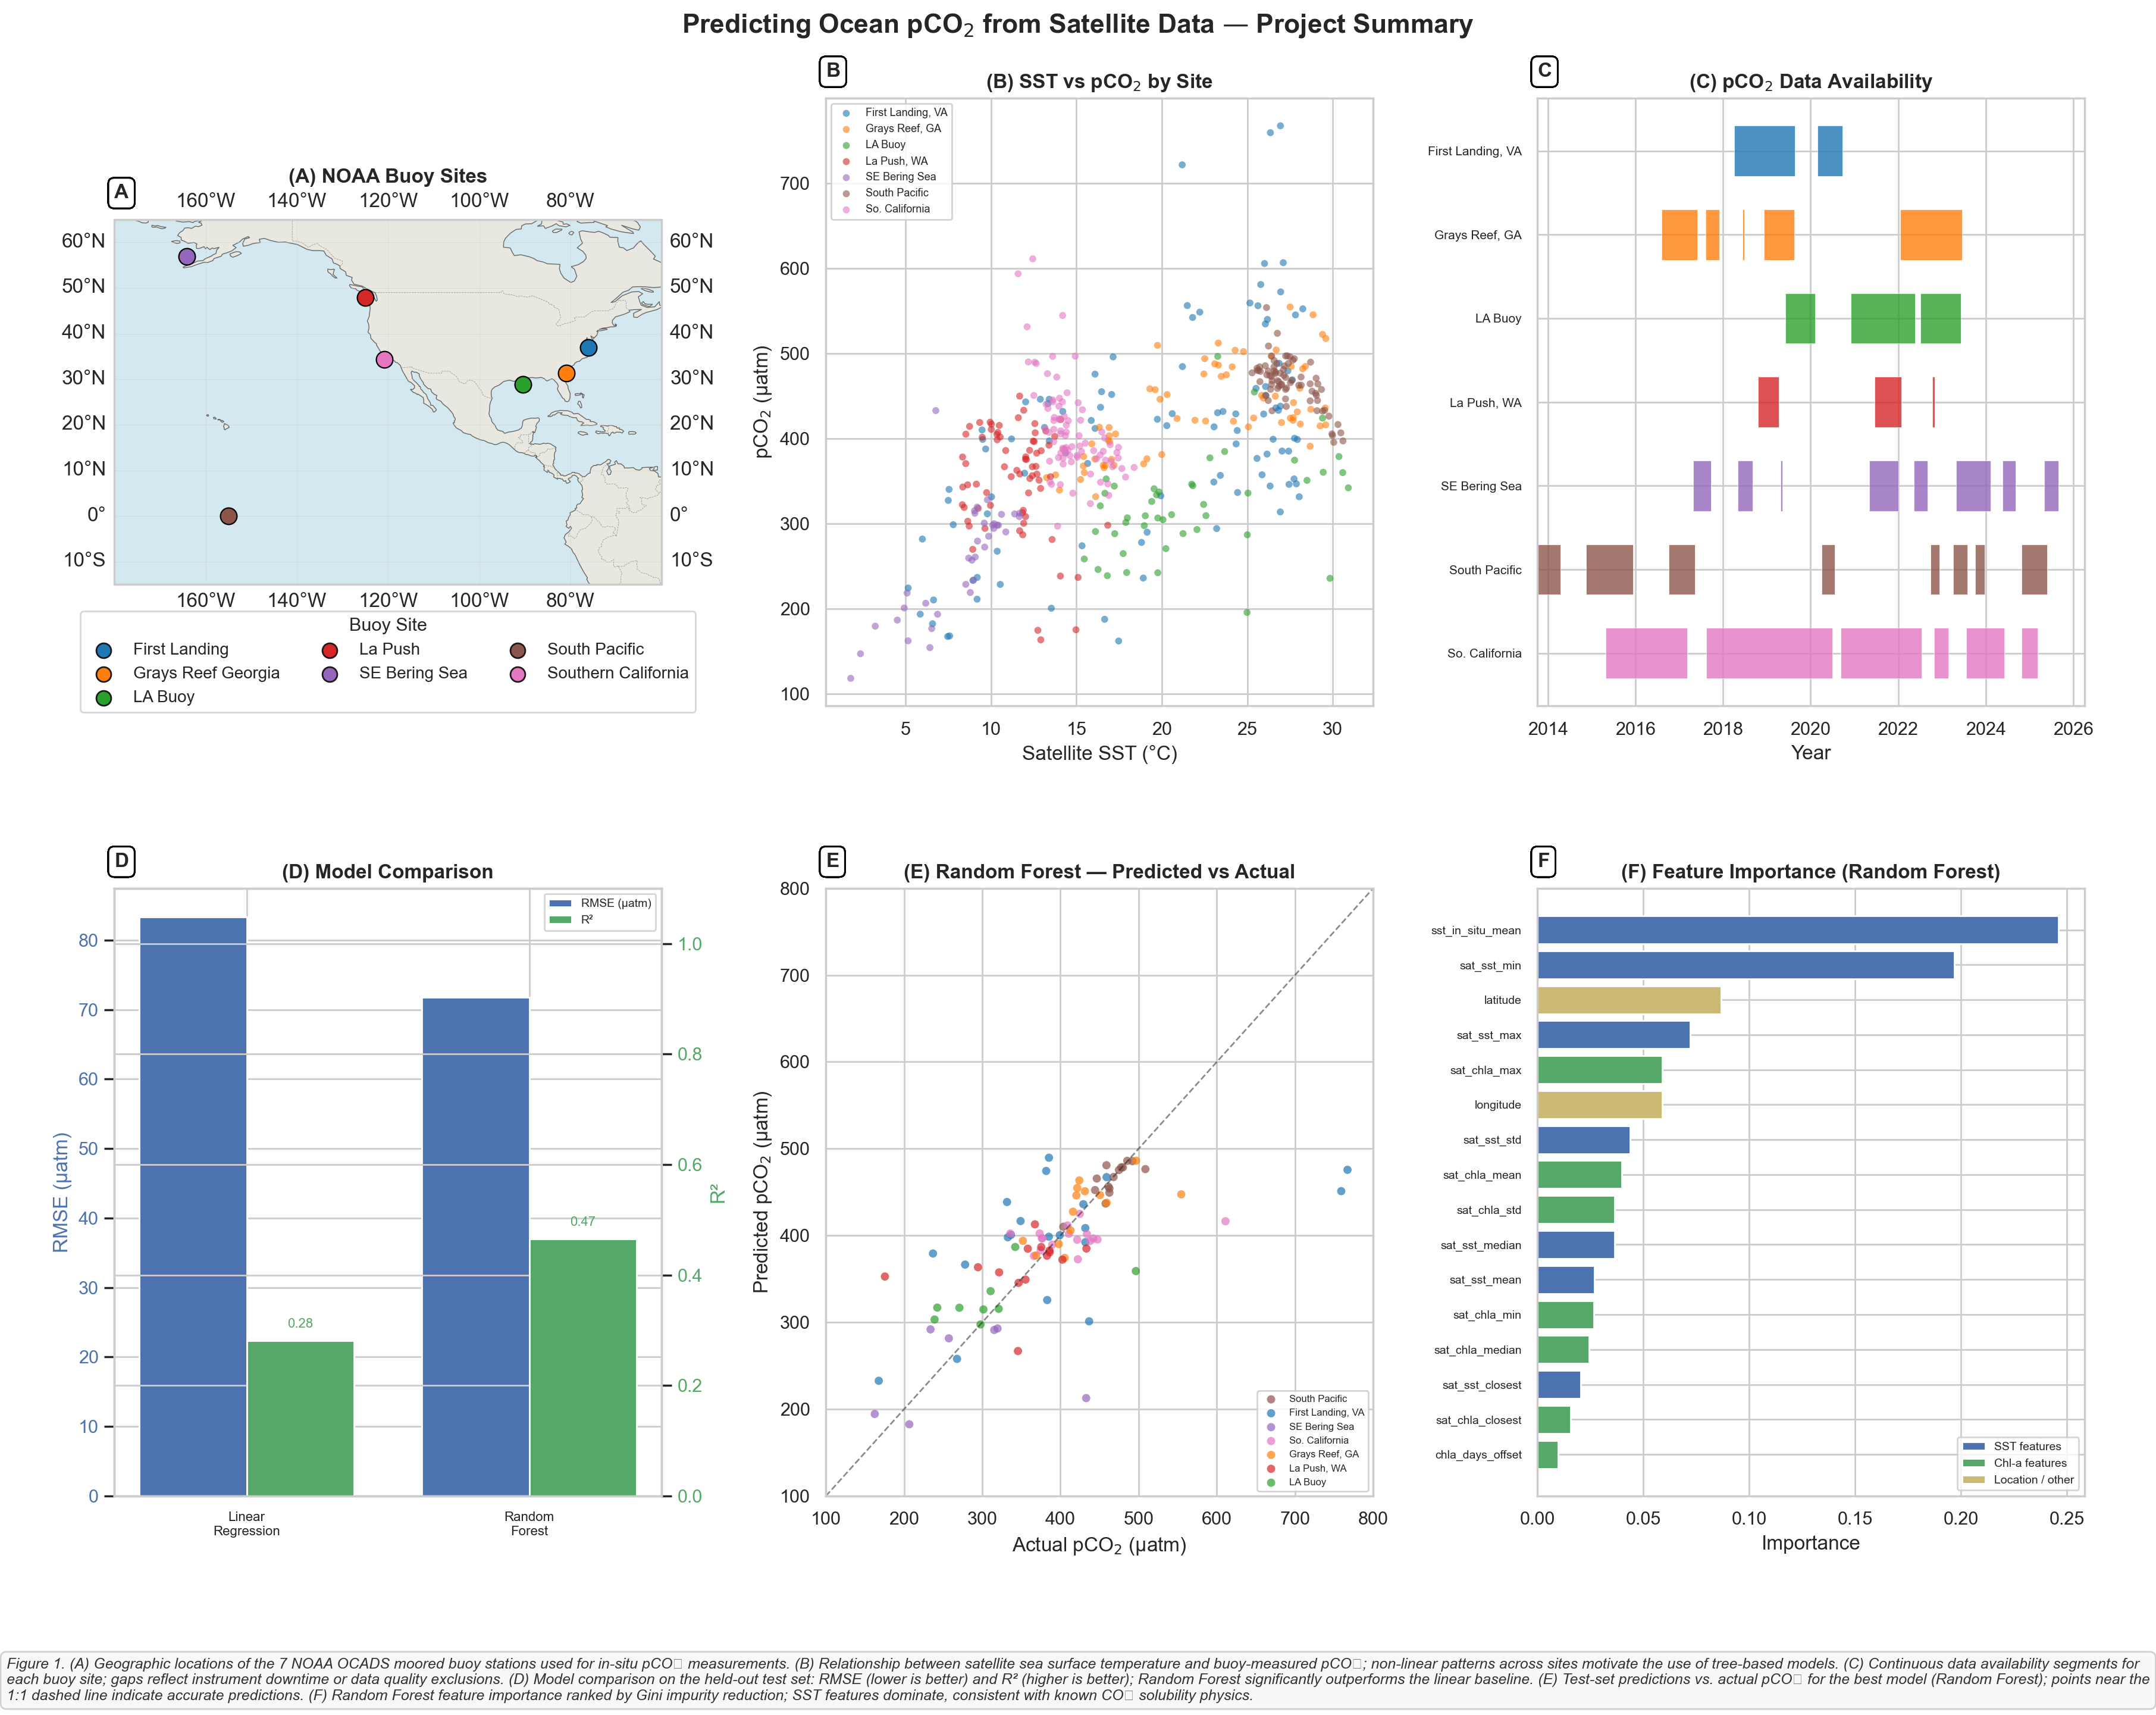

In [179]:
from IPython.display import display, Image

display(Image(filename=str(PLOT_DIR / "summary_figure_6panel.png")))

In [180]:
# Create a separate caption page as a PDF
import matplotlib.pyplot as plt

fig_caption, ax_caption = plt.subplots(figsize=(8.5, 11))
ax_caption.axis('off')

caption = (
    "Figure 1. (A) Geographic locations of the 7 NOAA OCADS moored buoy stations used for in-situ pCO₂ measurements. "
    "(B) Relationship between satellite sea surface temperature and buoy-measured pCO₂; non-linear patterns across sites motivate the use of tree-based models. "
    "(C) Continuous data availability segments for each buoy site; gaps reflect instrument downtime or data quality exclusions. "
    "(D) Model comparison on the held-out test set: RMSE (lower is better) and R² (higher is better); Random Forest significantly outperforms the linear baseline. "
    "(E) Test-set predictions vs. actual pCO₂ for the best model (Random Forest); points near the 1:1 dashed line indicate accurate predictions. "
    "(F) Random Forest feature importance ranked by Gini impurity reduction; SST features dominate, consistent with known CO₂ solubility physics."
)

fig_caption.text(0.5, 0.5, caption, ha='center', va='center', wrap=True, fontsize=12)
caption_pdf_path = PLOT_DIR / "summary_figure_caption.pdf"
fig_caption.savefig(caption_pdf_path, bbox_inches="tight")
plt.close(fig_caption)

print(f"Caption PDF saved to: {caption_pdf_path}")
# Restore site name labels for panel A (map)
# This should be placed after plotting the buoy sites on ax_a
print('Site coordinates for labeling:')
print(site_coords)
for _, row in site_coords.iterrows():
    print(f"Labeling {row['location']} at ({row['longitude']}, {row['latitude']})")
    ax_a.text(
        row['longitude'], row['latitude'], str(row['location']),
        transform=ccrs.PlateCarree(),
        fontsize=12, fontweight='bold', ha='left', va='center',
        color='black',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.85, pad=0.3, linewidth=0.5),
        zorder=10
    )
# PANEL A: Plot buoy sites with unique colors and add a legend just below the axes (outside the image)
site_colors = dict(zip(site_coords['location'], sns.color_palette('tab10', n_colors=len(site_coords))))

handles = []
labels = []
for _, row in site_coords.iterrows():
    h = ax_a.scatter(
        row['longitude'], row['latitude'],
        s=80, color=site_colors[row['location']], marker='o', edgecolor='k', zorder=3, transform=ccrs.PlateCarree(),
        label=row['location']
    )
    handles.append(h)
    labels.append(row['location'])
by_label = dict(zip(labels, handles))
legend = ax_a.legend(by_label.values(), by_label.keys(), loc='lower center', bbox_to_anchor=(0.5, -0.35),
                     fontsize=10, title='Buoy Site', title_fontsize=11, frameon=True, ncol=3, borderaxespad=0.0)
legend.set_zorder(30)

C:\Users\Owner\AppData\Local\Temp\ipykernel_8656\3891577532.py:18: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig_caption.savefig(caption_pdf_path, bbox_inches="tight")


Caption PDF saved to: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\ML2026_Orrand\final project deliverables\summary_figure_caption.pdf
Site coordinates for labeling:
              location  latitude  longitude
0        First Landing    36.998    -76.088
1   Grays Reef Georgia    31.399    -80.869
2              LA Buoy    28.869    -90.480
3              La Push    47.964   -124.958
4        SE Bering Sea    56.865   -164.065
5        South Pacific    -0.001   -154.919
6  Southern California    34.308   -120.814
Labeling First Landing at (-76.088, 36.998)
Labeling Grays Reef Georgia at (-80.869, 31.399)
Labeling LA Buoy at (-90.48, 28.869)
Labeling La Push at (-124.958, 47.964)
Labeling SE Bering Sea at (-164.065, 56.864999999999995)
Labeling South Pacific at (-154.919, -0.001)
Labeling Southern California at (-120.814, 34.308)
